In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny, swin_v2_b, Swin_V2_B_Weights
import numpy as np
from xgboost import XGBClassifier
import os
import pandas as pd
from glob import glob
import rasterio as rio
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import compute_sample_weight
from src.mslandcover.models import HRNetSegmentationModel
from src.mslandcover.config import LEGEND_CLASSES, LEGEND_COLORS_RGB, HRNET_W18_CONFIG, HRNET_W48_CONFIG

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [7]:
target_paths = glob('data/png_images/batch_0/target/*.tif')
input_paths = [x.replace('target', 'input_tif') for x in target_paths]

img_paths_df = pd.DataFrame({'input': input_paths, 'target': target_paths})
img_paths_df['X'] = img_paths_df['input'].apply(lambda x: rio.open(x).read())
img_paths_df['y'] = img_paths_df['target'].apply(lambda x: rio.open(x).read())
print(f'Total number of images: {len(img_paths_df)}')

dataset_mean = torch.load('./weights/pretrain_mean.pth', weights_only=True).numpy()
dataset_std = torch.load('./weights/pretrain_std.pth', weights_only=True).numpy()

img_paths_df['X_norm'] = img_paths_df['X'].apply(lambda x: ((x.transpose(1, 2, 0) - dataset_mean) / dataset_std).transpose(2, 0, 1))

# add hand-crafted features
def caculate_ndvi(X):
    # nir band is 0
    # red band is 1
    X = X.astype(np.float32)
    return (X[0] - X[1]) / (X[0] + X[1])

def caculate_ndwi(X):
    # nir band is 0
    # green band is 2
    X = X.astype(np.float32)
    return (X[2] - X[0]) / (X[2] + X[0])

def caclulate_gndvi(X):
    # nir band is 0
    # green band is 2
    X = X.astype(np.float32)
    return (X[0] - X[2]) / (X[0] + X[2])

img_paths_df['ndvi'] = img_paths_df['X'].apply(caculate_ndvi)
img_paths_df['ndwi'] = img_paths_df['X'].apply(caculate_ndwi)
img_paths_df['gndvi'] = img_paths_df['X'].apply(caclulate_gndvi)

Total number of images: 100


C:\Users\dh2306\AppData\Local\Temp\ipykernel_39172\3427927454.py:19: RuntimeWarning: invalid value encountered in divide
  return (X[0] - X[1]) / (X[0] + X[1])
C:\Users\dh2306\AppData\Local\Temp\ipykernel_39172\3427927454.py:25: RuntimeWarning: invalid value encountered in divide
  return (X[2] - X[0]) / (X[2] + X[0])
C:\Users\dh2306\AppData\Local\Temp\ipykernel_39172\3427927454.py:31: RuntimeWarning: invalid value encountered in divide
  return (X[0] - X[2]) / (X[0] + X[2])


In [ ]:
class ConvNext_Tiny_FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1).features
        
    def forward(self, x):
        feature_maps = []
        for i, block in enumerate(self.feature_extractor):
            x = block(x)
            if (i + 1) % 2 == 0: # only use every 2nd block
                feature_maps.append(F.interpolate(x, size=(64, 64), mode='bilinear', align_corners=True))
        return torch.concatenate(feature_maps, dim=1)



class SwinTransformer_FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.feature_extractor = swin_v2_b(weights=Swin_V2_B_Weights.IMAGENET1K_V1).features
    
    def forward(self, x):
        feature_maps = []
        for i, block in enumerate(self.feature_extractor):
            x = block(x)
            if (i + 1) % 2 == 0:
                feature_maps.append(F.interpolate(x.permute(0, 3, 1, 2), size=(64, 64), mode='bilinear', align_corners=True))
        return torch.concatenate(feature_maps, dim=1)



def get_device() -> torch.device:
    
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif torch.backends.mps.is_available():
        return torch.device('mps')
    else:
        return torch.device('cpu')

for model_name in ['hrnet_w18', 'hrnet_w48', 'convnext_tiny', 'swin_v2_b']:
    
    for weights in ['imagenet', 'hsv']:
        
        if model_name in ('convnext_tiny', 'swin_v2_b') and weights == 'hsv':
            continue
    
        if model_name == 'hrnet_w18':
            config = HRNET_W18_CONFIG
        
        elif model_name == 'hrnet_w48':
            config = HRNET_W48_CONFIG
        
        if model_name.startswith('hrnet'):
            model = HRNetSegmentationModel(config).eval()
            model.load_state_dict(torch.load(f'./weights/{model_name}/{weights}.pth', map_location='cpu', weights_only=True), strict=False)
            model = model.encoder()

        elif model_name == 'convnext_tiny':
            model = ConvNext_Tiny_FeatureExtractor().eval()
        elif model_name == 'swin_v2_b':
            model = SwinTransformer_FeatureExtractor().eval()
        
        

In [ ]:


device = get_device()
batch_size = 4
n_deep_features = {}

for weights in ['imagenet', 'hsv_simclr', 'hsv', 'hsv_w48', 'convnext_tiny_inet', 'swin_v2_b_inet']:
    
    z_list = []
    if weights == 'imagenet':
        model = HRNetSegmentationModel(HRNET_W18_CONFIG, img_decoder_head=False, aux_simclr_head=False).eval()
        model.load_encoder_weights(torch.load('weights/hrnet_w18/imagenet.pth', weights_only=True, map_location='cpu'))
        model = model.encoder # only use the encoder for HRNet
    elif weights == 'hsv_simclr':
        model = HRNetSegmentationModel(HRNET_W18_CONFIG, img_decoder_head=False, aux_simclr_head=False).eval()
        model.load_state_dict(torch.load('weights/hrnet_w18/hsv_simclr_old.pth', weights_only=True, map_location='cpu'), strict=False)
        model = model.encoder
    elif weights == 'hsv':
        model = HRNetSegmentationModel(HRNET_W18_CONFIG, img_decoder_head=False, aux_simclr_head=False).eval()
        model.load_state_dict(torch.load('weights/hrnet_w18/hsv.pth', weights_only=True, map_location='cpu'), strict=False)
        model = model.encoder
    elif weights == 'hsv_w48':
        model = HRNetSegmentationModel(HRNET_W48_CONFIG, img_decoder_head=False, aux_simclr_head=False).eval()
        model.load_state_dict(torch.load('weights/hrnet_w48/hsv.pth', weights_only=True, map_location='cpu'), strict=False)
        model = model.encoder
    elif weights == 'convnext_tiny_inet':
        model = ConvNext_Tiny_FeatureExtractor().eval()
    else:
        model = SwinTransformer_FeatureExtractor().eval()
    model = model.to(device)
    
    for i in range(0, len(img_paths_df), batch_size):
        X_batch = torch.from_numpy(np.stack(img_paths_df['X_norm'].values[i:i+batch_size])).to(device).to(torch.float32)
        with torch.no_grad():
            z_batch = model(X_batch)
        z_batch = F.interpolate(z_batch, size=(256, 256), mode='bilinear', align_corners=True)
        z_batch = z_batch.detach().to('cpu').numpy()
        z_list.extend(list(z_batch))
    
    img_paths_df[f'z_{weights}'] = z_list
    n_deep_features[weights] = z_list[0].shape[0]
    print(f'Number of deep features per pixel for {weights}: {n_deep_features[weights]}')

Number of deep features per pixel for imagenet: 270
Number of deep features per pixel for hsv_simclr: 270
Number of deep features per pixel for hsv: 270
Number of deep features per pixel for hsv_w48: 720
Number of deep features per pixel for convnext_tiny_inet: 1440
Number of deep features per pixel for swin_v2_b_inet: 1920


In [9]:
# append the hand-crafted features to the model output
offset = (256 - 192) // 2
features_dict = {}
for weights in ['imagenet', 'hsv_simclr', 'hsv', 'hsv_w48', 'convnext_tiny_inet', 'swin_v2_b_inet']:
    deep_features = np.stack(img_paths_df[f'z_{weights}'].values)[:, :, offset:-offset, offset:-offset]

    aggregated_features = np.concatenate([
        deep_features, 
        np.stack(img_paths_df['ndvi'].values)[:, None, offset:-offset, offset:-offset], 
        np.stack(img_paths_df['ndwi'].values)[:, None, offset:-offset, offset:-offset], 
        np.stack(img_paths_df['gndvi'].values)[:, None, offset:-offset, offset:-offset], 
        np.stack(img_paths_df['X'].values)[:,0][:, None, offset:-offset, offset:-offset],
        np.stack(img_paths_df['X'].values)[:,1][:, None, offset:-offset, offset:-offset],
        np.stack(img_paths_df['X'].values)[:,2][:, None, offset:-offset, offset:-offset]],
    axis=1)
    features_dict[weights] = list(aggregated_features)
    n_features = aggregated_features.shape[1]
    print(f'Total number of features from model {weights}: {n_features}')

Total number of features from model imagenet: 276
Total number of features from model hsv_simclr: 276
Total number of features from model hsv: 276
Total number of features from model hsv_w48: 726
Total number of features from model convnext_tiny_inet: 1446
Total number of features from model swin_v2_b_inet: 1926


In [10]:
def plot_confusion_matrix(y, y_pred, labels=None, title='Confusion Matrix'):
    print(labels)
    # generate nice-looking confusion matrix
    cm = confusion_matrix(y, y_pred, normalize='true')

    # mask 0 values out such that they are not displayed
    # cm = np.ma.masked_where(cm == 0, cm)

    true_positives = np.ma.masked_where(~(np.eye(cm.shape[0], dtype=bool)), cm)
    false_positives = np.ma.masked_where(np.eye(cm.shape[0], dtype=bool), cm)
    false_positives = np.ma.masked_where(false_positives == 0, false_positives)

    _, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(true_positives, cmap='Greens', vmin=0, vmax=1, alpha=0.5)
    ax.imshow(false_positives, cmap='Reds', vmin=0, vmax=0.5, alpha=0.5)

    # set axis labels
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    # set labels
    if labels is not None:
        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right')
        ax.set_yticklabels(labels)

    # create gridlines
    ax.set_xticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(labels), 1), minor=True)
    ax.grid(which='minor', color='k', linestyle='-', linewidth=0.5)

    ax.set_title(title)

    # include the values in the cells
    for i in range(len(labels)):
        for j in range(len(labels)):
            if cm[i, j] > 0:
                ax.text(j, i, f'{cm[i, j]*100:.1f}%', ha='center', va='center')

    plt.show()

Train images: 70
Test images: 30
Train size: 2534921
Test size: 1075141
Class Open Water - probability: 0.029302688328354216
Class Impervious (raised structures) - probability: 0.012731363225915128
Class Impervious (paved surfaces) - probability: 0.03268701470381128
Class Barren Land - probability: 0.08894636164203934
Class Forest - probability: 0.540292971654738
Class Herbaceous - probability: 0.2051539278738864
Class Cultivated Crops - probability: 0.05348845190836322
Class Unclassified - probability: 0.03739722066289245
Evaluating model weights:  imagenet
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.25      0.19      0.21      1406
Impervious (raised structures)       0.30      0.41      0.35     11866
   Impervious (paved surfaces)       0.38      0.58      0.46     39156
                   Barren Land       0.53      0.52      0.52     91012
                   

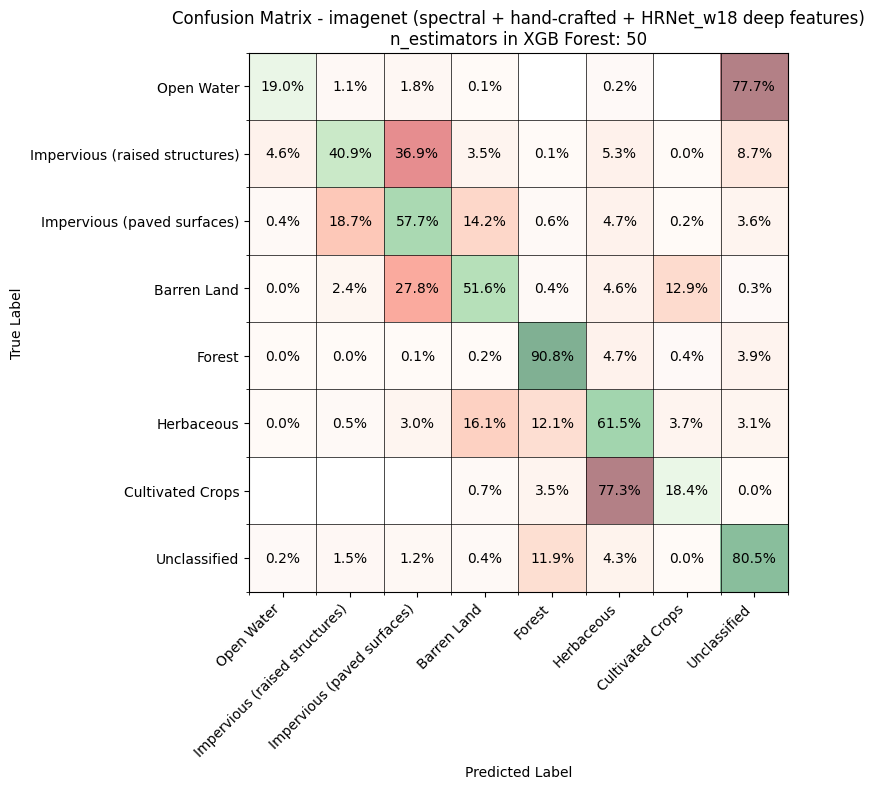

Evaluating model weights:  hsv_simclr
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.00      0.00      0.00      1406
Impervious (raised structures)       0.30      0.44      0.36     11866
   Impervious (paved surfaces)       0.36      0.57      0.44     39156
                   Barren Land       0.54      0.59      0.56     91012
                        Forest       0.94      0.90      0.92    610383
                    Herbaceous       0.60      0.61      0.60    212383
              Cultivated Crops       0.37      0.15      0.22     66914
                  Unclassified       0.49      0.78      0.61     42021

                      accuracy                           0.74   1075141
                     macro avg       0.45      0.51      0.46   1075141
                  weighted avg       0.75      0.74      0.74   1075141

['Open Water', 'Impervious (raised struc

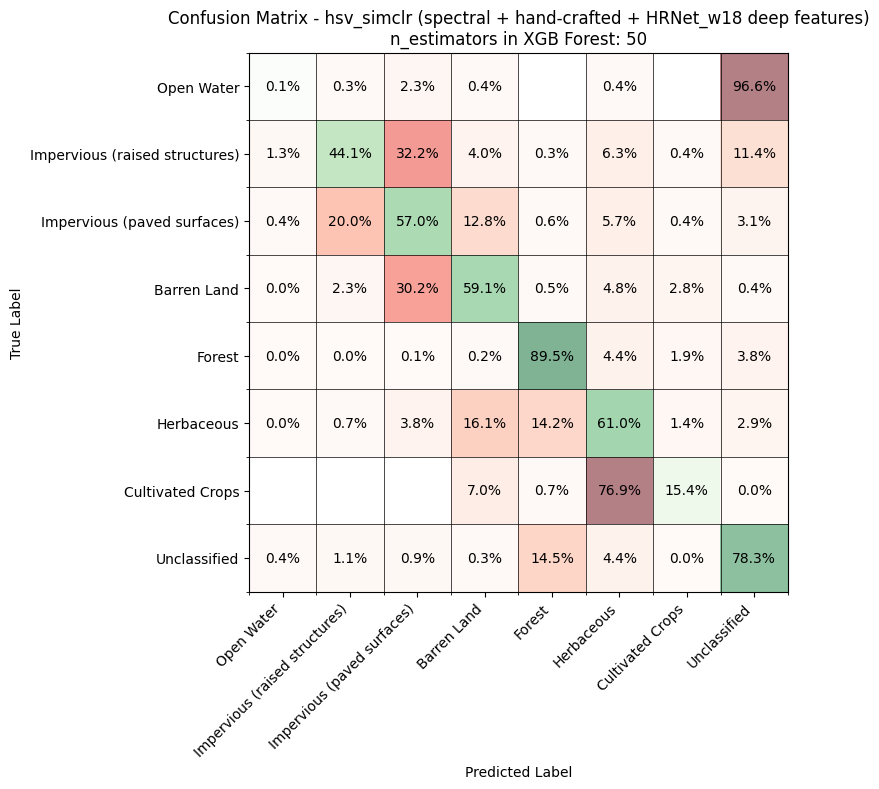

Evaluating model weights:  hsv
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.06      0.03      0.04      1406
Impervious (raised structures)       0.29      0.37      0.33     11866
   Impervious (paved surfaces)       0.35      0.54      0.42     39156
                   Barren Land       0.58      0.64      0.61     91012
                        Forest       0.94      0.91      0.93    610383
                    Herbaceous       0.58      0.62      0.60    212383
              Cultivated Crops       0.09      0.01      0.02     66914
                  Unclassified       0.50      0.76      0.60     42021

                      accuracy                           0.75   1075141
                     macro avg       0.42      0.49      0.44   1075141
                  weighted avg       0.74      0.75      0.74   1075141

['Open Water', 'Impervious (raised structures)'

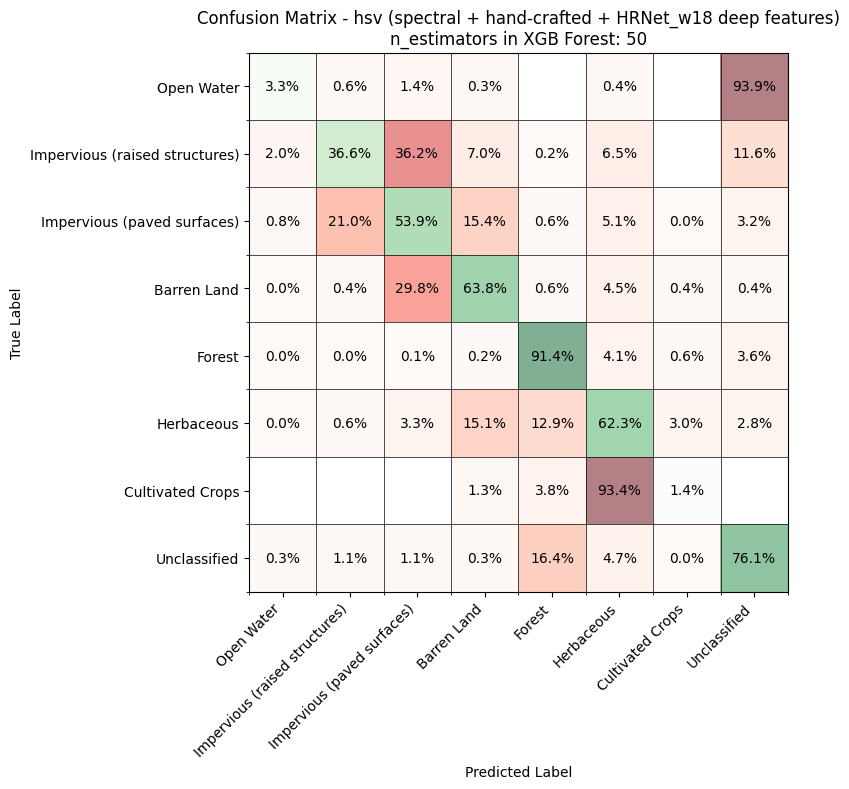

Evaluating model weights:  hsv_w48
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.00      0.01      0.01      1406
Impervious (raised structures)       0.27      0.43      0.33     11866
   Impervious (paved surfaces)       0.33      0.48      0.39     39156
                   Barren Land       0.53      0.63      0.58     91012
                        Forest       0.95      0.90      0.93    610383
                    Herbaceous       0.59      0.55      0.57    212383
              Cultivated Crops       0.50      0.26      0.34     66914
                  Unclassified       0.48      0.83      0.61     42021

                      accuracy                           0.75   1075141
                     macro avg       0.46      0.51      0.47   1075141
                  weighted avg       0.76      0.75      0.75   1075141

['Open Water', 'Impervious (raised structur

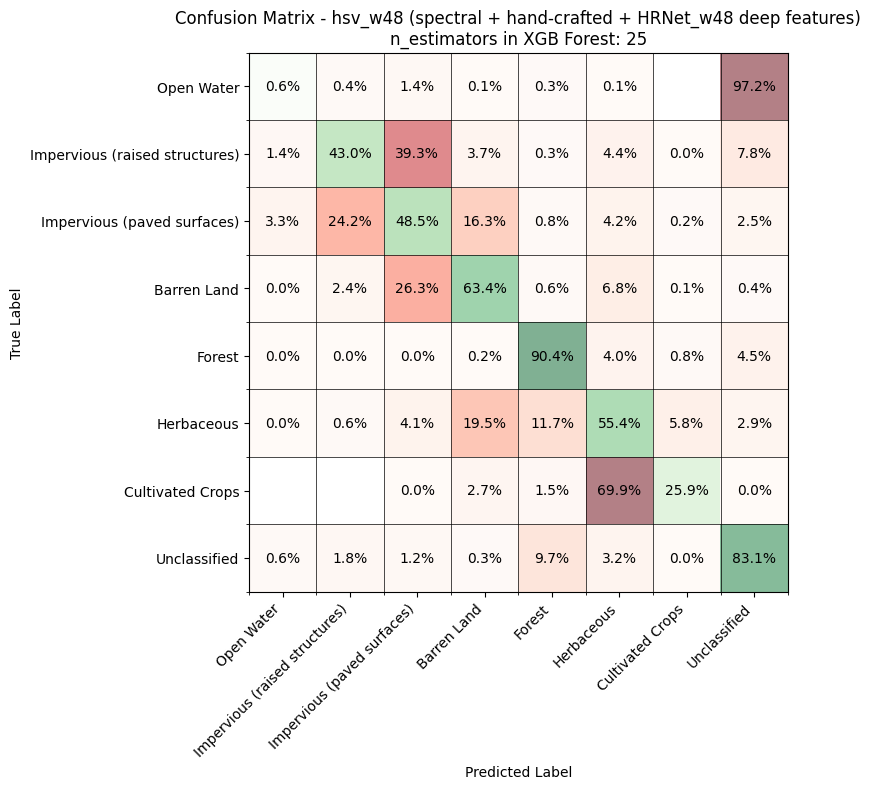

Evaluating model weights:  none
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.09      0.02      0.03      1406
Impervious (raised structures)       0.30      0.69      0.41     11866
   Impervious (paved surfaces)       0.32      0.55      0.41     39156
                   Barren Land       0.63      0.54      0.58     91012
                        Forest       0.95      0.66      0.78    610383
                    Herbaceous       0.63      0.54      0.58    212383
              Cultivated Crops       0.21      0.50      0.30     66914
                  Unclassified       0.28      0.87      0.42     42021

                      accuracy                           0.62   1075141
                     macro avg       0.42      0.55      0.44   1075141
                  weighted avg       0.75      0.62      0.66   1075141

['Open Water', 'Impervious (raised structures)

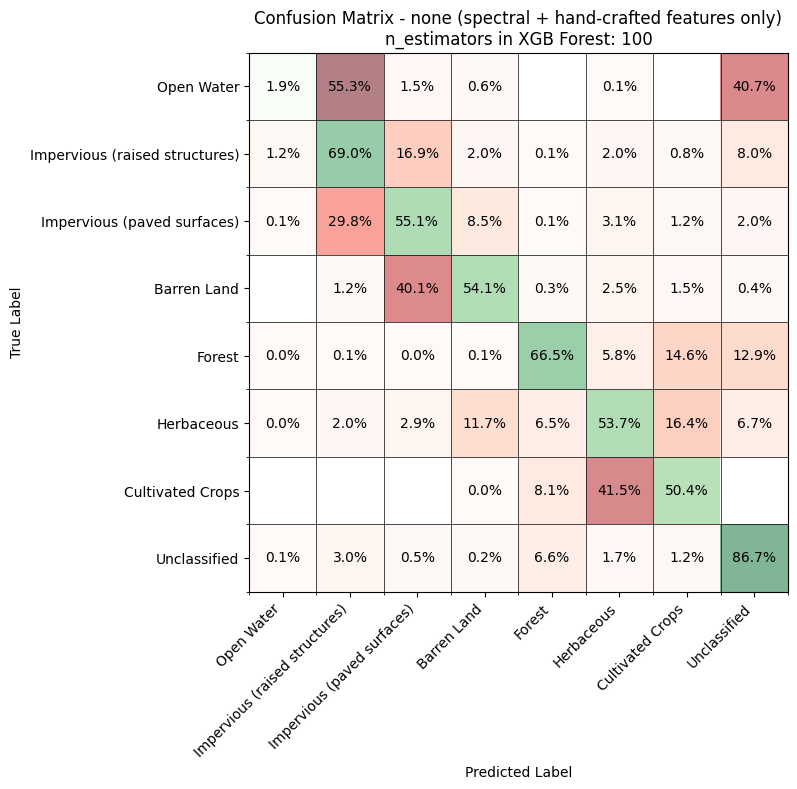

Evaluating model weights:  convnext_tiny_inet
Preparing data


MemoryError: Unable to allocate 13.7 GiB for an array with shape (2534921, 1446) and data type float32

In [11]:
features_dict['y'] = list(img_paths_df['y'].apply(lambda x: x[0, offset:-offset, offset:-offset]).values)
features_df = pd.DataFrame(features_dict)

train_df, test_df = train_test_split(features_df, test_size=0.3, random_state=1701)

print(f'Train images: {len(train_df)}')
print(f'Test images: {len(test_df)}')

offset = (256 - 192) // 2 # only keep the center 192x192 pixels due to edge effects

y_train = np.stack(train_df['y'].values).flatten()
y_test = np.stack(test_df['y'].values).flatten()
y_preds = {}

zero_indices_train = (y_train == 0)
zero_indices_test = (y_test == 0)

y_train = y_train[~zero_indices_train] - 1
y_test = y_test[~zero_indices_test] - 1

print(f'Train size: {y_train.shape[0]}')
print(f'Test size: {y_test.shape[0]}')

probs = np.bincount(y_train) / len(y_train)
sample_weights = compute_sample_weight('balanced', y=y_train)
xgb_models = {}
for i in range(len(probs)):
    print(f'Class {LEGEND_CLASSES[i+1]} - probability: {probs[i]}')

for model in ['imagenet', 'hsv_simclr', 'hsv', 'hsv_w48', 'none', 'convnext_tiny_inet', 'swin_v2_b_inet']:
    print("Evaluating model weights: ", model)
    
    print('Preparing data')
    
    n_features = n_deep_features[model] + 6 if model in n_deep_features else n_deep_features['imagenet'] + 6
    
    if model == 'none':
        X_train = np.stack(train_df['imagenet']).transpose(0, 2, 3, 1).reshape(-1, n_features)[:, -6:]
        X_test = np.stack(test_df['imagenet']).transpose(0, 2, 3, 1).reshape(-1, n_features)[:, -6:]

    else:
        X_train = np.stack(train_df[model]).transpose(0, 2, 3, 1).reshape(-1, n_features)
        X_test = np.stack(test_df[model]).transpose(0, 2, 3, 1).reshape(-1, n_features)
    
    # print(len(X))
    
    X_train = X_train[~zero_indices_train] 
    X_test = X_test[~zero_indices_test] 
    
    print('Training XGBoost model')
    
    if model == 'none':
        n_estimators = 100
    elif model in ('imagenet', 'hsv_simclr', 'hsv'):
        n_estimators = 50
    else:
        n_estimators = 25
    xgb = XGBClassifier(n_estimators=n_estimators, n_jobs=-1, random_state=1701)
    xgb.fit(X_train, y_train, sample_weight=sample_weights)
    
    xgb_models[model] = xgb
    
    print('Evaluating model')
    y_pred = xgb.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=list(LEGEND_CLASSES.values())[1:]))
    y_preds[model] = y_pred
    
    title = f'Confusion Matrix - {model}'
    if model == 'none':
        title += ' (spectral + hand-crafted features only)'
    elif model in ('imagenet', 'hsv_simclr', 'hsv'):
        title += ' (spectral + hand-crafted + HRNet_w18 deep features)'
    elif model == 'hsv_w48':
        title += ' (spectral + hand-crafted + HRNet_w48 deep features)'
    else:
        title += ' (spectral + hand-crafted + deep features (Imagenet weights))'
    title += f'\nn_estimators in XGB Forest: {n_estimators}'
    plot_confusion_matrix(y_test, y_pred, labels=list(LEGEND_CLASSES.values())[1:], title=title)


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
metrics_dict = {}
for model in ['imagenet', 'hsv_simclr', 'none', 'convnext_tiny_inet', 'swin_v2_b_inet']:
    
    y_pred = y_preds[model]
    if model in ('imagenet', 'hsv_simclr'):
        model = 'hrnet_w18_' + model
    if model == 'none':
        model = 'spectral_hc_only'
    
    metrics_dict[model] = {
        'overall_accuracy': accuracy_score(y_test, y_pred),
        'user_accuracy': precision_score(y_test, y_pred, average='weighted'),
        'producer_accuracy': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'macro_ua': precision_score(y_test, y_pred, average='macro'),
        'macro_pa': recall_score(y_test, y_pred, average='macro'),
        'macro_f1': f1_score(y_test, y_pred, average='macro')
    }
metrics_df = pd.DataFrame(metrics_dict).T
metrics_df

,overall_accuracy,user_accuracy,producer_accuracy,f1_score,macro_ua,macro_pa,macro_f1
hrnet_w18_imagenet,0.790711,0.779638,0.790711,0.783193,0.451629,0.506268,0.473115
hrnet_w18_hsv_simclr,0.793960,0.778776,0.793960,0.784547,0.454163,0.507730,0.474998
spectral_hc_only,0.671424,0.766227,0.671424,0.705036,0.457010,0.508439,0.444651
convnext_tiny_inet,0.809513,0.806759,0.809513,0.801809,0.616063,0.649384,0.613086
swin_v2_b_inet,0.787300,0.789434,0.787300,0.784064,0.576059,0.613993,0.583348


In [ ]:
def create_color_lcmap(y_pred):
    y_pred_rgb = np.zeros((y_pred.shape[0], y_pred.shape[1], 3), dtype=np.uint8)
    
    for i in range(8):
        y_pred_rgb[y_pred == i] = LEGEND_COLORS_RGB[i]
    
    return y_pred_rgb

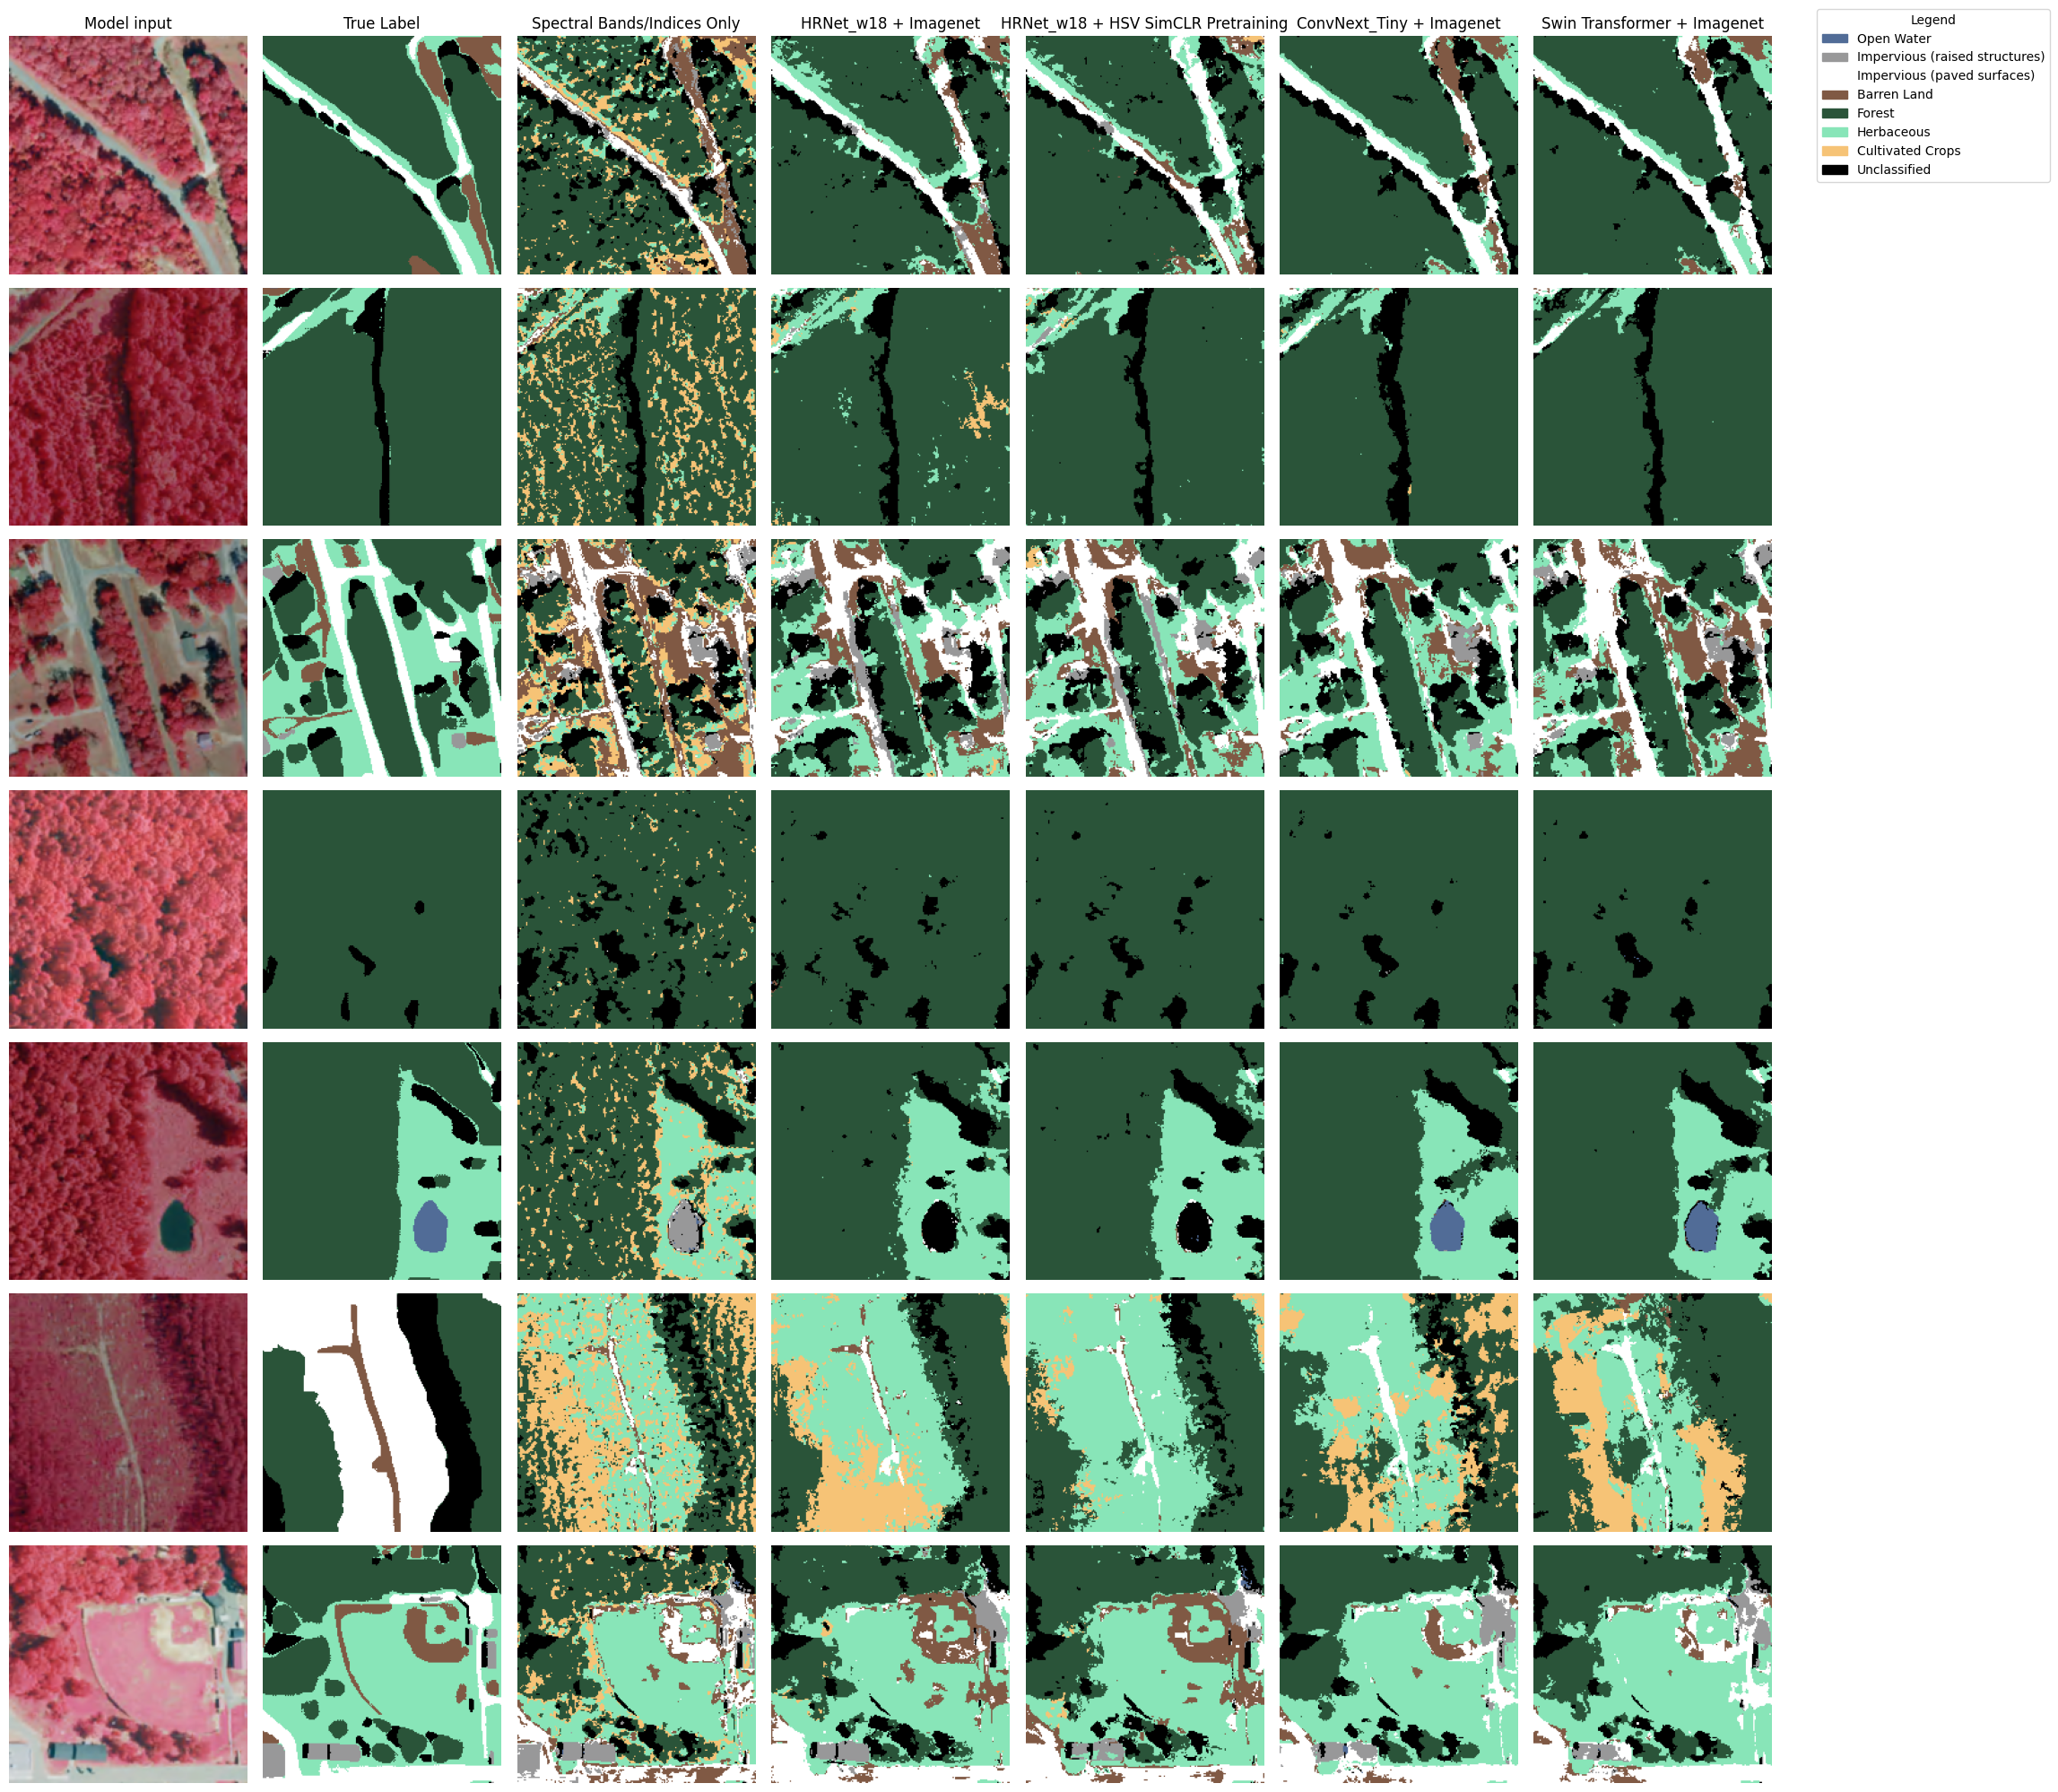

In [ ]:
sample_idx = 2
array_sample_slice = slice(sample_idx * (192 ** 2), (sample_idx + 1) * (192 ** 2))
fig, ax = plt.subplots(9, 7, figsize=(20, 20))

ax[0][0].set_title('Model input')
ax[0][1].set_title('True Label')
ax[0][2].set_title('Spectral Bands/Indices Only')
ax[0][3].set_title('HRNet_w18 + Imagenet')
ax[0][4].set_title('HRNet_w18 + HSV SimCLR Pretraining')
ax[0][5].set_title('HRNet_w18 + HSV Pretraining')
ax[0][6].set_title('HRNet_w48 + HSV Pretraining')
ax[0][7].set_title('ConvNext_Tiny + Imagenet')
ax[0][8].set_title('Swin Transformer + Imagenet')

for i in range(len(ax)):
    
    sample = test_df.iloc[i]
    
    x_sample = sample['imagenet'][-3:].transpose(1, 2, 0)
    x_sample = (x_sample - x_sample.min()) / (x_sample.max() + x_sample.min())
    ax[i][0].imshow(x_sample)
    
    y_true_sample = sample['y'].squeeze()
    y_true_sample_color = create_color_lcmap(y_true_sample)
    ax[i][1].imshow(y_true_sample_color)
    
    y_pred_spectral = xgb_models['none'].predict(sample['imagenet'][-6:, : , :].transpose(1, 2, 0).reshape(-1, 6)).reshape(192, 192)
    y_pred_spectral_color = create_color_lcmap(y_pred_spectral + 1)
    ax[i][2].imshow(y_pred_spectral_color)
    
    y_pred_hrnet_imagenet = xgb_models['imagenet'].predict(sample['imagenet'].transpose(1, 2, 0).reshape(-1, 6 + n_deep_features['imagenet'])).reshape(192, 192)
    y_pred_hrnet_imagenet_color = create_color_lcmap(y_pred_hrnet_imagenet + 1)
    ax[i][3].imshow(y_pred_hrnet_imagenet_color)
    
    y_pred_hrnet_hsv_simclr = xgb_models['hsv_simclr'].predict(sample['hsv_simclr'].transpose(1, 2, 0).reshape(-1, 6 + n_deep_features['hsv_simclr'])).reshape(192, 192)
    y_pred_hrnet_hsv_simclr_color = create_color_lcmap(y_pred_hrnet_hsv_simclr + 1)
    ax[i][4].imshow(y_pred_hrnet_hsv_simclr_color)
    
    y_pred_hrnet_hsv = xgb_models['hsv'].predict(sample['hsv'].transpose(1, 2, 0).reshape(-1, 6 + n_deep_features['hsv'])).reshape(192, 192)
    y_pred_hrnet_hsv_color = create_color_lcmap(y_pred_hrnet_hsv + 1)
    ax[i][5].imshow(y_pred_hrnet_hsv_color)
    
    y_pred_hrnet_hsv_w48 = xgb_models['hsv_w48'].predict(sample['hsv_w48'].transpose(1, 2, 0).reshape(-1, 6 + n_deep_features['hsv_w48'])).reshape(192, 192)
    y_pred_hrnet_hsv_w48_color = create_color_lcmap(y_pred_hrnet_hsv_w48 + 1)
    ax[i][6].imshow(y_pred_hrnet_hsv_w48_color)
    
    y_pred_convnext_tiny = xgb_models['convnext_tiny_inet'].predict(sample['convnext_tiny_inet'].transpose(1, 2, 0).reshape(-1, 6 + n_deep_features['convnext_tiny_inet'])).reshape(192, 192)
    y_pred_convnext_tiny_color = create_color_lcmap(y_pred_convnext_tiny + 1)
    ax[i][7].imshow(y_pred_convnext_tiny_color)
    
    y_pred_swin_v2_b = xgb_models['swin_v2_b_inet'].predict(sample['swin_v2_b_inet'].transpose(1, 2, 0).reshape(-1, 6 + n_deep_features['swin_v2_b_inet'])).reshape(192, 192)
    y_pred_swin_v2_b_color = create_color_lcmap(y_pred_swin_v2_b + 1)
    ax[i][8].imshow(y_pred_swin_v2_b_color)
    
    for j in range(9):
        ax[i][j].axis('off')

legend_colors_rgb_norm = [(v[0] / 255, v[1] / 255, v[2] / 255) for v in list(LEGEND_COLORS_RGB.values())[1:]]
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=legend_colors_rgb_norm[i]) for i in range(8)], labels=list(LEGEND_CLASSES.values())[1:], loc='upper right', title='Legend', bbox_to_anchor=(1.15, 1))
fig.tight_layout()

Evaluating model weights:  imagenet
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.00      0.00      0.00      1137
Impervious (raised structures)       0.16      0.19      0.17     13348
   Impervious (paved surfaces)       0.25      0.21      0.23     44409
                   Barren Land       0.55      0.62      0.58     51838
                        Forest       0.85      0.81      0.83    558159
                    Herbaceous       0.68      0.62      0.65    199922
              Cultivated Crops       0.00      0.00      0.00     35848
                  Unclassified       0.32      0.61      0.42     43613

                      accuracy                           0.68    948274
                     macro avg       0.35      0.38      0.36    948274
                  weighted avg       0.70      0.68      0.69    948274

['Open Water', 'Impervious (raised structu

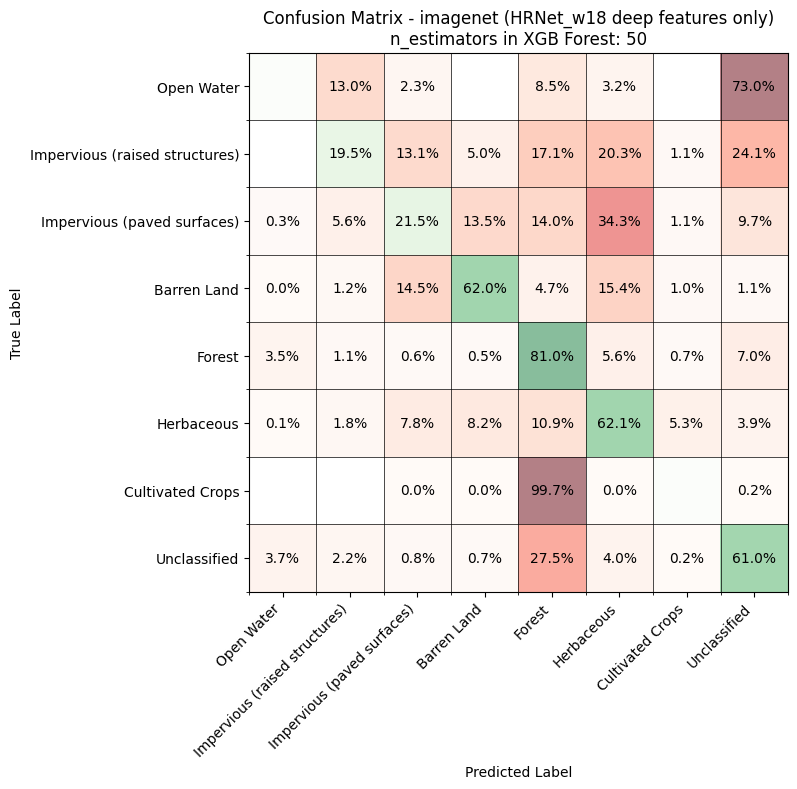

Evaluating model weights:  hsv_simclr
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.00      0.00      0.00      1137
Impervious (raised structures)       0.15      0.20      0.17     13348
   Impervious (paved surfaces)       0.25      0.25      0.25     44409
                   Barren Land       0.38      0.59      0.46     51838
                        Forest       0.85      0.85      0.85    558159
                    Herbaceous       0.66      0.55      0.60    199922
              Cultivated Crops       0.00      0.00      0.00     35848
                  Unclassified       0.33      0.57      0.41     43613

                      accuracy                           0.69    948274
                     macro avg       0.33      0.37      0.34    948274
                  weighted avg       0.69      0.69      0.68    948274

['Open Water', 'Impervious (raised struc

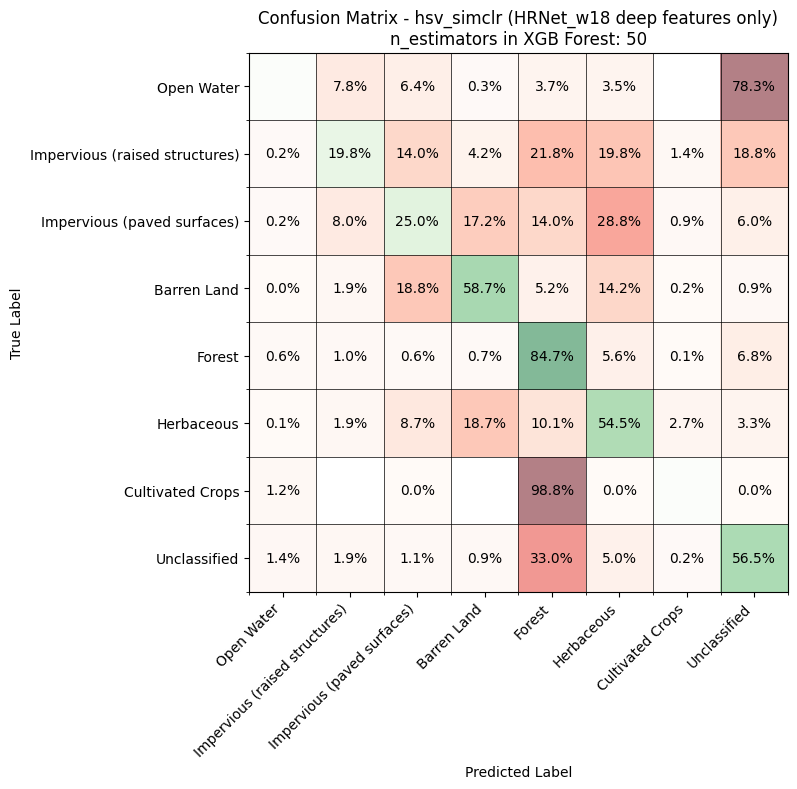

Evaluating model weights:  convnext_tiny_inet
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.90      0.67      0.77      1137
Impervious (raised structures)       0.46      0.69      0.55     13348
   Impervious (paved surfaces)       0.60      0.77      0.67     44409
                   Barren Land       0.70      0.53      0.61     51838
                        Forest       0.92      0.90      0.91    558159
                    Herbaceous       0.80      0.80      0.80    199922
              Cultivated Crops       0.35      0.05      0.09     35848
                  Unclassified       0.44      0.79      0.56     43613

                      accuracy                           0.81    948274
                     macro avg       0.65      0.65      0.62    948274
                  weighted avg       0.82      0.81      0.81    948274

['Open Water', 'Impervious (rais

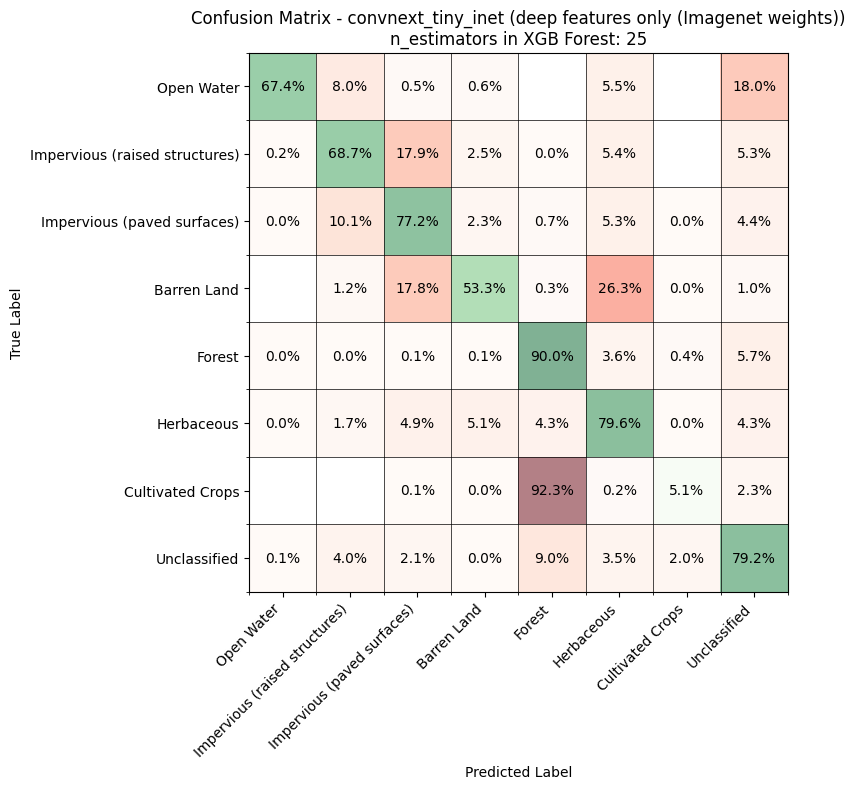

Evaluating model weights:  swin_v2_b_inet
Preparing data
Training XGBoost model
Evaluating model
                                precision    recall  f1-score   support

                    Open Water       0.65      0.66      0.66      1137
Impervious (raised structures)       0.43      0.71      0.53     13348
   Impervious (paved surfaces)       0.57      0.73      0.64     44409
                   Barren Land       0.55      0.37      0.44     51838
                        Forest       0.91      0.91      0.91    558159
                    Herbaceous       0.76      0.61      0.68    199922
              Cultivated Crops       0.02      0.03      0.03     35848
                  Unclassified       0.42      0.69      0.52     43613

                      accuracy                           0.76    948274
                     macro avg       0.54      0.59      0.55    948274
                  weighted avg       0.78      0.76      0.77    948274

['Open Water', 'Impervious (raised s

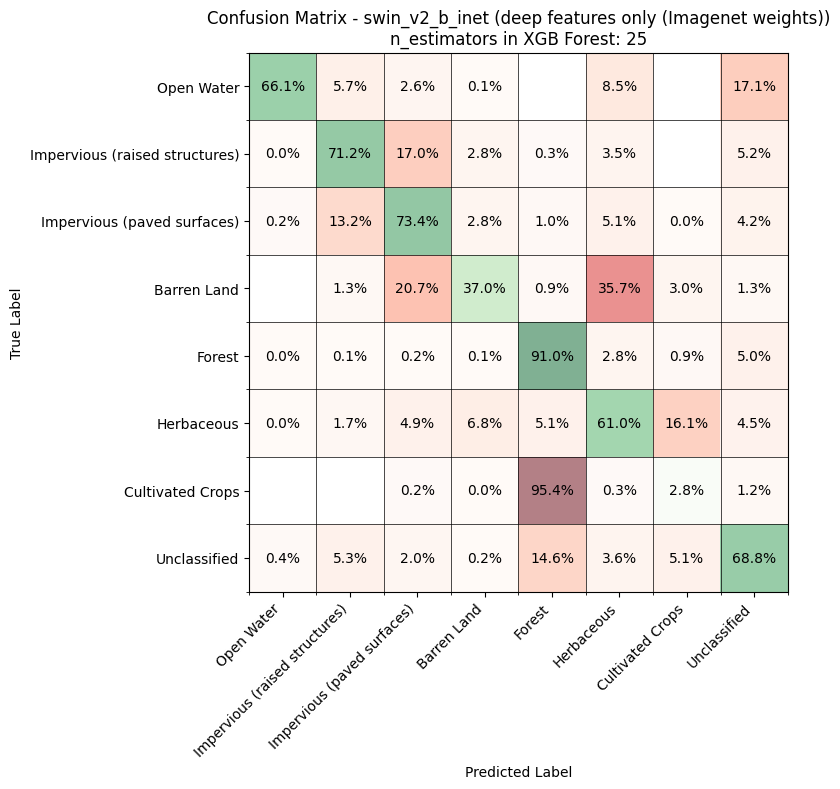

In [ ]:
# now lets do the same with NO spectral features
for model in ['imagenet', 'hsv_simclr', 'hsv', 'hsv_w48', 'convnext_tiny_inet', 'swin_v2_b_inet']:
    print("Evaluating model weights: ", model)
    
    print('Preparing data')
    
    n_features = n_deep_features[model] + 6 if model in n_deep_features else n_deep_features['imagenet'] + 6
    
    if model == 'none':
        X_train = np.stack(train_df['imagenet']).transpose(0, 2, 3, 1).reshape(-1, n_features)[:, -6:]
        X_test = np.stack(test_df['imagenet']).transpose(0, 2, 3, 1).reshape(-1, n_features)[:, -6:]

    else:
        X_train = np.stack(train_df[model]).transpose(0, 2, 3, 1).reshape(-1, n_features)[:, :-6]
        X_test = np.stack(test_df[model]).transpose(0, 2, 3, 1).reshape(-1, n_features)[:, :-6] # remove the spectral features
    
    X_train = X_train[~zero_indices_train] 
    X_test = X_test[~zero_indices_test] 
    
    print('Training XGBoost model')
    
    if model == 'none':
        n_estimators = 100
    elif model in ('imagenet', 'hsv_simclr', 'hsv', 'hsv_w48'):
        n_estimators = 50
    else:
        n_estimators = 25
    xgb = XGBClassifier(n_estimators=n_estimators, n_jobs=-1, random_state=1701)
    xgb.fit(X_train, y_train, sample_weight=sample_weights)
    
    xgb_models[model + '_no_spectrals'] = xgb
    
    print('Evaluating model')
    y_pred = xgb.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=list(LEGEND_CLASSES.values())[1:]))
    y_preds[model + '_no_spectrals'] = y_pred
    
    title = f'Confusion Matrix - {model}'
    if model == 'none':
        title += ' (spectral + hand-crafted features only)'
    elif model in ('imagenet', 'hsv_simclr', 'hsv'):
        title += ' (HRNet_w18 deep features only)'
    elif model == 'hsv_w48':
        title += ' (HRNet_w48 deep features only)'
    else:
        title += ' (deep features only (Imagenet weights))'
    title += f'\nn_estimators in XGB Forest: {n_estimators}'
    plot_confusion_matrix(y_test, y_pred, labels=list(LEGEND_CLASSES.values())[1:], title=title)


In [ ]:
metrics_dict_2 = {}
for model in ['imagenet_no_spectrals', 'hsv_simclr_no_spectrals', 'convnext_tiny_inet_no_spectrals', 'swin_v2_b_inet_no_spectrals']:
    
    y_pred = y_preds[model]
    if model in ('imagenet', 'hsv_simclr'):
        model = 'hrnet_w18_' + model
    
    metrics_dict_2[model] = {
        'overall_accuracy': accuracy_score(y_test, y_pred),
        'user_accuracy': precision_score(y_test, y_pred, average='weighted'),
        'producer_accuracy': recall_score(y_test, y_pred, average='weighted'),
        'f1_score': f1_score(y_test, y_pred, average='weighted'),
        'macro_ua': precision_score(y_test, y_pred, average='macro'),
        'macro_pa': recall_score(y_test, y_pred, average='macro'),
        'macro_f1': f1_score(y_test, y_pred, average='macro')
    }
# metrics_df_2 = pd.DataFrame(metrics_dict_2).T
# 
metrics_df = pd.concat([metrics_df, pd.DataFrame(metrics_dict_2).T])
display(metrics_df)

,overall_accuracy,user_accuracy,producer_accuracy,f1_score,macro_ua,macro_pa,macro_f1
imagenet_no_spectrals,0.682455,0.701522,0.682455,0.689236,0.351095,0.383813,0.361090
hsv_simclr_no_spectrals,0.686036,0.690645,0.686036,0.684423,0.327711,0.374047,0.342983
convnext_tiny_inet_no_spectrals,0.811621,0.815666,0.811621,0.805605,0.645485,0.650521,0.620181
swin_v2_b_inet_no_spectrals,0.762341,0.778227,0.762341,0.765190,0.538858,0.589087,0.551088


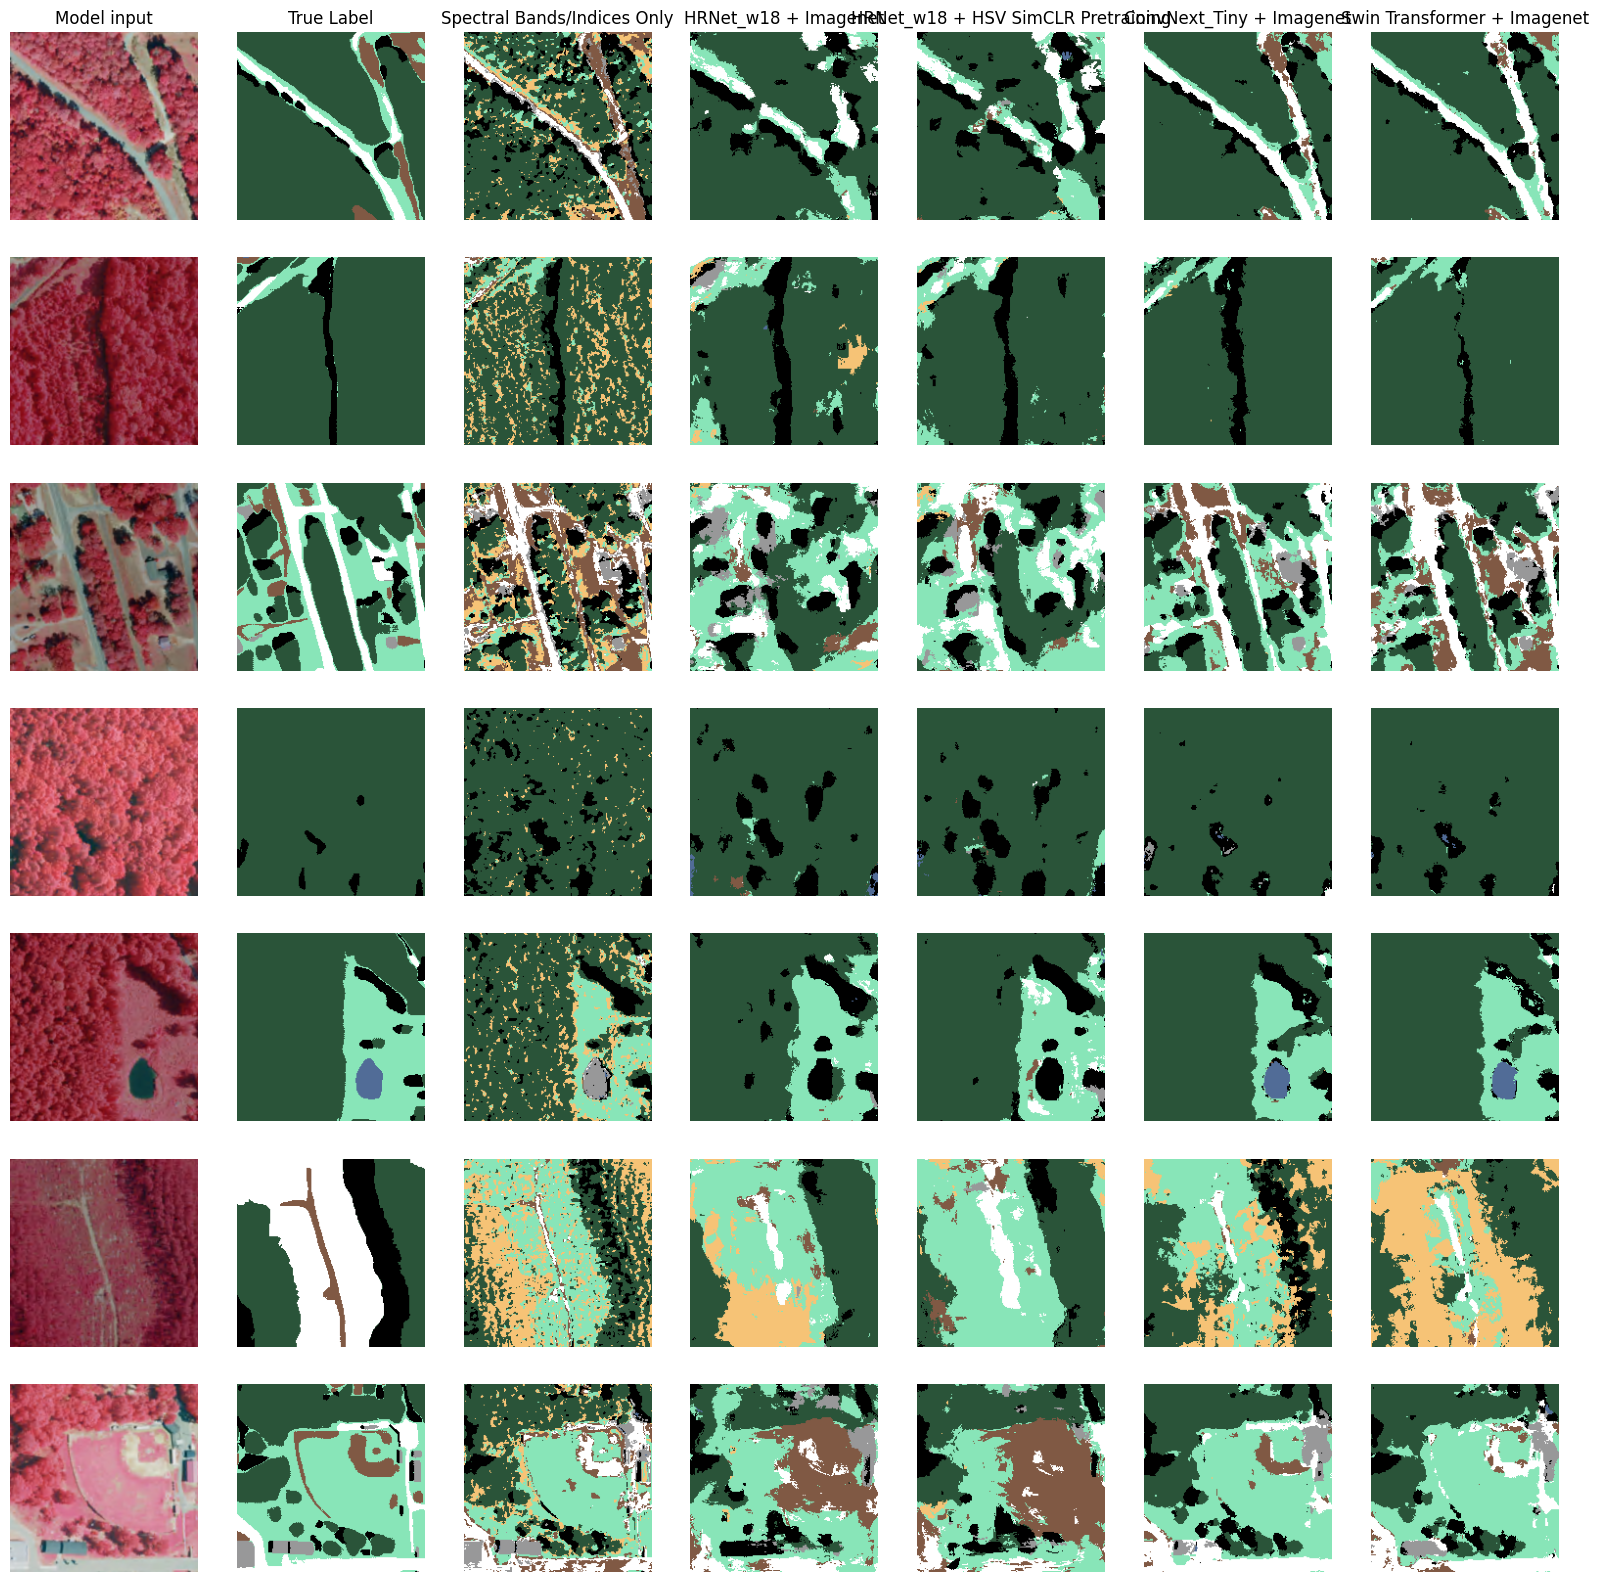

In [ ]:
ig, ax = plt.subplots(9, 7, figsize=(20, 20))

ax[0][0].set_title('Model input')
ax[0][1].set_title('True Label')
ax[0][2].set_title('Spectral Bands/Indices Only')
ax[0][3].set_title('HRNet_w18 + Imagenet')
ax[0][4].set_title('HRNet_w18 + HSV SimCLR Pretraining')
ax[0][5].set_title('HRNet_w18 + HSV Pretraining')
ax[0][6].set_title('HRNet_w48 + HSV Pretraining')
ax[0][7].set_title('ConvNext_Tiny + Imagenet')
ax[0][8].set_title('Swin Transformer + Imagenet')

for i in range(len(ax)):
    
    sample = test_df.iloc[i]
    
    x_sample = sample['imagenet'][-3:].transpose(1, 2, 0)
    x_sample = (x_sample - x_sample.min()) / (x_sample.max() + x_sample.min())
    ax[i][0].imshow(x_sample)
    
    y_true_sample = sample['y'].squeeze()
    y_true_sample_color = create_color_lcmap(y_true_sample)
    ax[i][1].imshow(y_true_sample_color)
    
    y_pred_spectral = xgb_models['none'].predict(sample['imagenet'][-6:, : , :].transpose(1, 2, 0).reshape(-1, 6)).reshape(192, 192)
    y_pred_spectral_color = create_color_lcmap(y_pred_spectral + 1)
    ax[i][2].imshow(y_pred_spectral_color)
    
    y_pred_hrnet_imagenet = xgb_models['imagenet_no_spectrals'].predict(sample['imagenet'].transpose(1, 2, 0)[:, :, :-6].reshape(-1, n_deep_features['imagenet'])).reshape(192, 192)
    y_pred_hrnet_imagenet_color = create_color_lcmap(y_pred_hrnet_imagenet + 1)
    ax[i][3].imshow(y_pred_hrnet_imagenet_color)
    
    y_pred_hrnet_hsv_simclr = xgb_models['hsv_simclr_no_spectrals'].predict(sample['hsv_simclr'].transpose(1, 2, 0)[:, :, :-6].reshape(-1, n_deep_features['hsv_simclr'])).reshape(192, 192)
    y_pred_hrnet_hsv_simclr_color = create_color_lcmap(y_pred_hrnet_hsv_simclr + 1)
    ax[i][4].imshow(y_pred_hrnet_hsv_simclr_color)
    
    y_pred_hrnet_hsv = xgb_models['hsv_no_spectrals'].predict(sample['hsv'].transpose(1, 2, 0)[:, :, :-6].reshape(-1, n_deep_features['hsv'])).reshape(192, 192)
    y_pred_hrnet_hsv_color = create_color_lcmap(y_pred_hrnet_hsv + 1)
    ax[i][5].imshow(y_pred_hrnet_hsv_color)
    
    y_pred_hrnet_hsv_w48 = xgb_models['hsv_w48_no_spectrals'].predict(sample['hsv_w48'].transpose(1, 2, 0)[:, :, :-6].reshape(-1, n_deep_features['hsv_w48'])).reshape(192, 192)
    y_pred_hrnet_hsv_w48_color = create_color_lcmap(y_pred_hrnet_hsv_w48 + 1)
    ax[i][6].imshow(y_pred_hrnet_hsv_w48_color)
    
    y_pred_convnext_tiny = xgb_models['convnext_tiny_inet_no_spectrals'].predict(sample['convnext_tiny_inet'].transpose(1, 2, 0)[:, :, :-6].reshape(-1, n_deep_features['convnext_tiny_inet'])).reshape(192, 192)
    y_pred_convnext_tiny_color = create_color_lcmap(y_pred_convnext_tiny + 1)
    ax[i][7].imshow(y_pred_convnext_tiny_color)
    
    y_pred_swin_v2_b = xgb_models['swin_v2_b_inet_no_spectrals'].predict(sample['swin_v2_b_inet'].transpose(1, 2, 0)[:, :, :-6].reshape(-1, n_deep_features['swin_v2_b_inet'])).reshape(192, 192)
    y_pred_swin_v2_b_color = create_color_lcmap(y_pred_swin_v2_b + 1)
    ax[i][8].imshow(y_pred_swin_v2_b_color)
    
    for j in range(9):
        ax[i][j].axis('off')

legend_colors_rgb_norm = [(v[0] / 255, v[1] / 255, v[2] / 255) for v in list(LEGEND_COLORS_RGB.values())[1:]]
fig.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=legend_colors_rgb_norm[i]) for i in range(8)], labels=list(LEGEND_CLASSES.values())[1:], loc='upper right', title='Legend', bbox_to_anchor=(1.15, 1))
fig.tight_layout()